# Can a $1 million movie be financially successful?

Graphs replicate the analysis in `low_budget_movies.sql` using the datasets in `output/`.
A **low-budget** movie = budget between \$100k and \$1M, `revenue > 1000`, `vote_count > 500`, released 2000+.
ROI = `(revenue - budget) / budget`.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# datasets from output/  (oscars_2.csv is the 'oscars' table)
tmdb    = pd.read_csv('output/tmdb.csv')
ratings = pd.read_csv('output/ratings.csv')
oscars  = pd.read_csv('output/oscars_2.csv')   # a.k.a. 'oscars'

tmdb['release_date'] = pd.to_datetime(tmdb['release_date'], errors='coerce')
tmdb['year'] = tmdb['release_date'].dt.year

# validated categorical / sequential palette (dataviz skill)
INK        = '#0b0b0b'
SECONDARY  = '#52514e'
GRID       = '#e6e6e3'
SURFACE    = '#fcfcfb'
SEQ = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
BLUE, POS, NEG = '#3987e5', '#1baf7a', '#e34948'

# ---- seaborn theme (applies to every chart below) ----
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
        'axes.edgecolor': GRID, 'grid.color': GRID, 'grid.linewidth': 0.8,
        'axes.grid.axis': 'y', 'axes.spines.top': False, 'axes.spines.right': False,
        'axes.spines.left': False, 'text.color': INK, 'axes.labelcolor': SECONDARY,
        'axes.titlecolor': INK, 'xtick.color': SECONDARY, 'ytick.color': SECONDARY,
        'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlesize': 15,
    },
)

def style_axes(ax, xlabel=None, ylabel=None, title=None, ygrid=True):
    """Shared finishing touches: title left-aligned, ticks flush, single-axis grid."""
    if title:  ax.set_title(title, loc='left', pad=14)
    ax.set_xlabel(xlabel or '')
    ax.set_ylabel(ylabel or '')
    ax.tick_params(length=0)
    ax.grid(axis='y' if ygrid else 'x', color=GRID)
    ax.grid(axis='x' if ygrid else 'y', visible=False)

print(f'tmdb {tmdb.shape}, ratings {ratings.shape}, oscars {oscars.shape}  |  seaborn {sns.__version__}')

tmdb (1451806, 25), ratings (1690132, 3), oscars (12137, 13)  |  seaborn 0.13.2


## Graph 1 — Average ROI by budget group
Replicates the `budget_group` CASE query. Shows how ROI changes as budget grows: the smallest-budget tier returns the most per dollar spent.

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/2248479872.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g1.index, y=g1.avg_roi, palette=SEQ[::-1][:len(g1)], edgecolor=SURFACE, linewidth=2, ax=ax)
/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/2248479872.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(g1.index, fontsize=10.5)


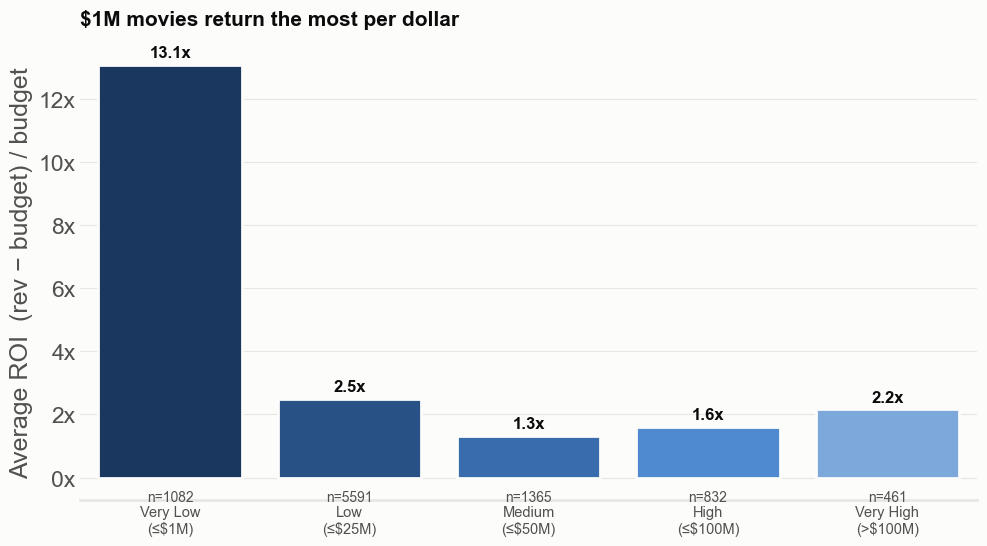

,movies,avg_roi
budget_group,,
Very Low\n(≤$1M),1082,13.062237
Low\n(≤$25M),5591,2.496632
Medium\n(≤$50M),1365,1.326622
High\n(≤$100M),832,1.607145
Very High\n(>$100M),461,2.157627


In [17]:
# WHERE budget > 100000 AND revenue > 0 AND vote_count > 0
b = tmdb[(tmdb.budget > 100000) & (tmdb.revenue > 0) & (tmdb.vote_count > 0)].copy()
b['roi'] = (b.revenue - b.budget) / b.budget

bins   = [100000, 1_000_000, 25_000_000, 50_000_000, 100_000_000, float('inf')]
labels = ['Very Low\n(≤$1M)', 'Low\n(≤$25M)', 'Medium\n(≤$50M)', 'High\n(≤$100M)', 'Very High\n(>$100M)']
b['budget_group'] = pd.cut(b.budget, bins=bins, labels=labels, right=True)

g1 = b.groupby('budget_group', observed=True).agg(movies=('roi', 'size'), avg_roi=('roi', 'mean')).reindex(labels)

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.barplot(x=g1.index, y=g1.avg_roi, palette=SEQ[::-1][:len(g1)], edgecolor=SURFACE, linewidth=2, ax=ax)
for i, (v, n) in enumerate(zip(g1.avg_roi, g1.movies)):
    ax.text(i, v + 0.15, f'{v:.1f}x', ha='center', va='bottom', color=INK, fontweight='bold', fontsize=12)
    ax.text(i, -0.4, f'n={n}', ha='center', va='top', color=SECONDARY, fontsize=10)

style_axes(ax, ylabel='Average ROI  (rev − budget) / budget', title='$1M movies return the most per dollar')
ax.set_xticklabels(g1.index, fontsize=10.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
ax.set_ylim(bottom=-0.7)
plt.tight_layout()
plt.savefig('output/graph1_roi_by_budget.png', dpi=150, bbox_inches='tight')
plt.show()
g1

## Graph 2 — ROI distribution of $1M movies
Replicates the `ROI_GROUPING` / `share_pct` query on the low-budget CTE. Shows what share of sub-$1M movies land in each ROI bucket — i.e. how often they actually succeed.

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/3110412302.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g2.index, y=g2.values, palette=colors, edgecolor=SURFACE, linewidth=2, ax=ax)
/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/3110412302.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(g2.index, fontsize=10.5)


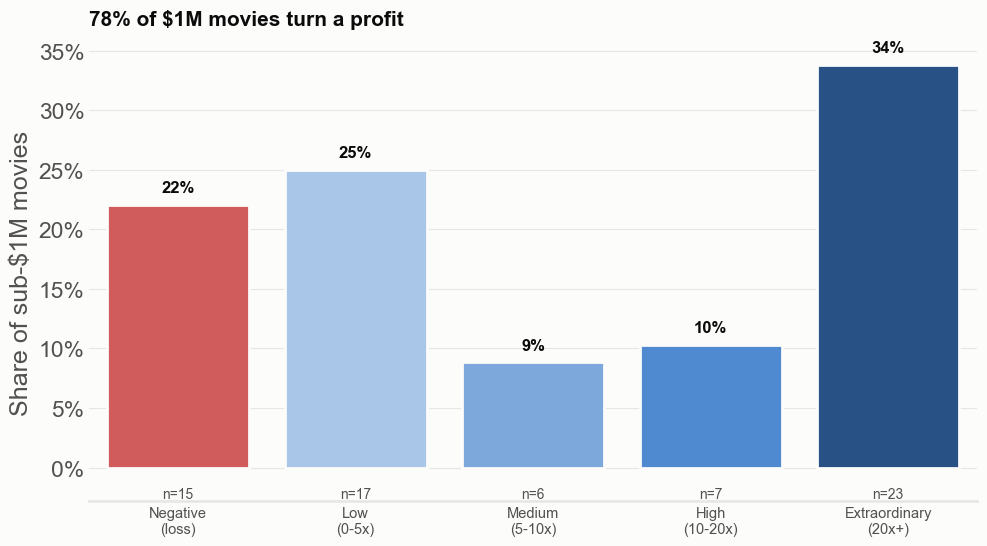

,share_pct,movies
roi_grouping,,
Negative\n(loss),22.1,15
Low\n(0-5x),25.0,17
Medium\n(5-10x),8.8,6
High\n(10-20x),10.3,7
Extraordinary\n(20x+),33.8,23


In [18]:
# LOW_BUDGET_MOVIES CTE: budget 100k-1M, revenue>1000, vote_count>500, year>=2000
low = tmdb[(tmdb.budget > 100000) & (tmdb.budget <= 1_000_000) &
           (tmdb.revenue > 1000) & (tmdb.vote_count > 500) & (tmdb.year >= 2000)].copy()
low['roi'] = (low.revenue - low.budget) / low.budget

def roi_group(r):
    if r < 0:  return 'Negative\n(loss)'
    if r < 5:  return 'Low\n(0-5x)'
    if r < 10: return 'Medium\n(5-10x)'
    if r < 20: return 'High\n(10-20x)'
    return 'Extraordinary\n(20x+)'

order = ['Negative\n(loss)', 'Low\n(0-5x)', 'Medium\n(5-10x)', 'High\n(10-20x)', 'Extraordinary\n(20x+)']
low['roi_grouping'] = low.roi.apply(roi_group)
g2 = (low.roi_grouping.value_counts(normalize=True) * 100).reindex(order).fillna(0)
counts = low.roi_grouping.value_counts().reindex(order).fillna(0).astype(int)

# color by polarity: loss = red, profit = blue ramp by strength
colors = [NEG, '#9ec5f4', '#6da7ec', '#3987e5', '#184f95']
fig, ax = plt.subplots(figsize=(10, 5.6))
sns.barplot(x=g2.index, y=g2.values, palette=colors, edgecolor=SURFACE, linewidth=2, ax=ax)
for i, (v, n) in enumerate(zip(g2.values, counts.values)):
    ax.text(i, v + 0.8, f'{v:.0f}%', ha='center', va='bottom', color=INK, fontweight='bold', fontsize=12)
    ax.text(i, -1.6, f'n={n}', ha='center', va='top', color=SECONDARY, fontsize=10)

profitable = 100 - g2.iloc[0]
style_axes(ax, ylabel='Share of sub-$1M movies', title=f'{profitable:.0f}% of $1M movies turn a profit')
ax.set_xticklabels(g2.index, fontsize=10.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylim(bottom=-2.8)
plt.tight_layout()
plt.savefig('output/graph2_roi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame({'share_pct': g2.round(1), 'movies': counts})

## Graph 3 — Do higher-rated movies earn more ROI?
Same population as the SQL: the **LOW_BUDGET_MOVIES** CTE inner-joined to `ratings`. Movies bucketed by `rating_group` CASE; bar shows **avg ROI** per bucket (table also reports `avg_revenue, avg_profit`), ordered by avg ROI — matching the query.

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/180452059.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot.index, y=plot.avg_roi, palette=SEQ[2:2 + len(plot)], edgecolor=SURFACE, linewidth=2, ax=ax)
/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/180452059.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot.index, fontsize=11)


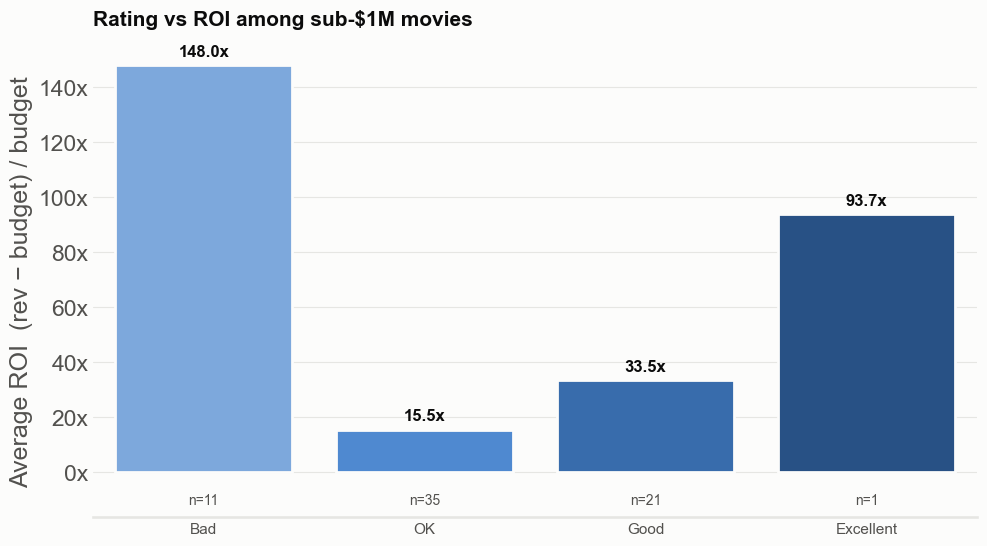

,movies,avg_revenue,avg_profit,avg_roi
rating_group,,,,
Bad,11,44972604.18,44282149.64,147.96
Excellent,1,14204632.00,14054632.00,93.70
Good,21,19829579.43,19144178.67,33.51
OK,35,7778447.29,7085379.89,15.53


In [19]:
# Do higher-rated movies earn more ROI?  -> restricted to the LOW_BUDGET_MOVIES CTE
# JOIN ratings ON ratings.tconst = LOW_BUDGET_MOVIES.imdb_id   (inner join)
lr = low.merge(ratings, left_on='imdb_id', right_on='tconst', how='inner')

def rating_group(v):
    if v < 4: return 'Terrible'
    if v < 6: return 'Bad'
    if v < 7: return 'OK'
    if v < 8: return 'Good'
    return 'Excellent'

lr['rating_group'] = lr.vote_average.apply(rating_group)
lr['profit'] = lr.revenue - lr.budget

# matches SELECT: movies, avg_revenue, avg_profit, avg_roi  (ORDER BY avg_roi DESC)
g3 = lr.groupby('rating_group', observed=True).agg(
    movies=('revenue', 'size'),
    avg_revenue=('revenue', 'mean'),
    avg_profit=('profit', 'mean'),
    avg_roi=('roi', 'mean'),
).sort_values('avg_roi', ascending=False).round(2)

# plot avg_roi, ordered by rating quality for readability
r_order = [g for g in ['Terrible', 'Bad', 'OK', 'Good', 'Excellent'] if g in g3.index]
plot = g3.reindex(r_order)
ymax = plot.avg_roi.max()

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.barplot(x=plot.index, y=plot.avg_roi, palette=SEQ[2:2 + len(plot)], edgecolor=SURFACE, linewidth=2, ax=ax)
for i, (v, n) in enumerate(zip(plot.avg_roi, plot.movies)):
    ax.text(i, v + ymax * 0.015, f'{v:.1f}x', ha='center', va='bottom', color=INK, fontweight='bold', fontsize=12)
    ax.text(i, -ymax * 0.05, f'n={n}', ha='center', va='top', color=SECONDARY, fontsize=10)

style_axes(ax, ylabel='Average ROI  (rev − budget) / budget', title='Rating vs ROI among sub-$1M movies')
ax.set_xticklabels(plot.index, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
ax.set_ylim(bottom=-ymax * 0.11)
plt.tight_layout()
plt.savefig('output/graph3_roi_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# table matching the SQL result (ORDER BY avg_roi DESC)
g3

## Graph 4 — Which genres win on a $1M budget?
Same **LOW_BUDGET_MOVIES** CTE. `main_genre` = first genre listed (`TRIM(SUBSTRING_INDEX(genres, ',', 1))`). Table reports `movies, avg_revenue, avg_profit, avg_roi` ordered by avg ROI (matching the query).

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_8635/13698613.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(plot.index, fontsize=11)


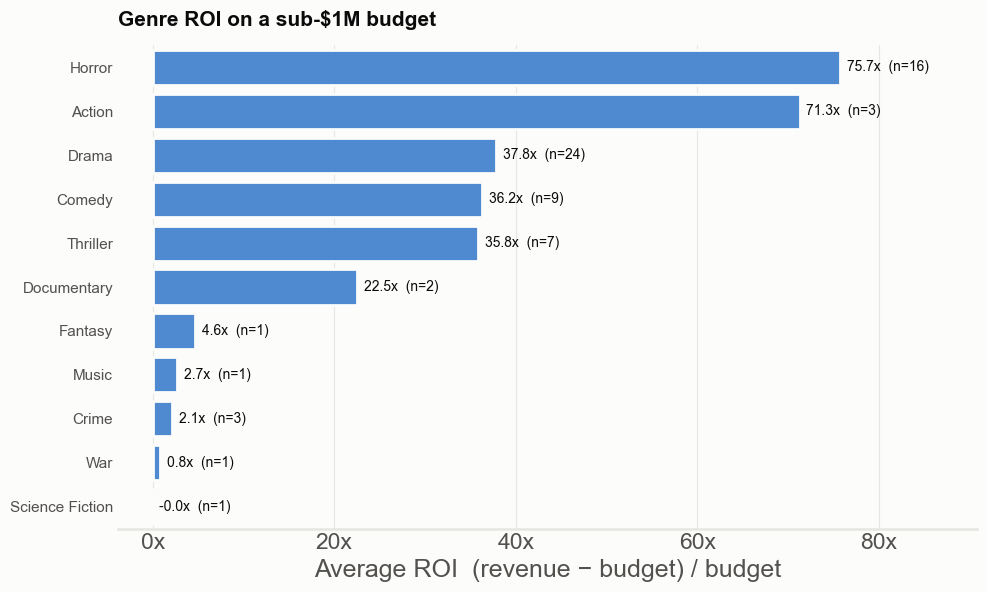

,movies,avg_revenue,avg_profit,avg_roi
main_genre,,,,
Horror,16,25201600.31,24449537.81,75.69
Action,3,51193426.33,50517142.33,71.28
Drama,24,9108541.08,8556854.71,37.82
Comedy,9,11301240.00,10754311.22,36.24
Thriller,7,36762917.43,35820060.29,35.80
Documentary,2,23482857.00,22482857.00,22.48
Fantasy,1,3000000.00,2467327.00,4.63
Music,1,3696196.00,2696196.00,2.70
Crime,3,2237423.67,1557951.00,2.13


In [20]:
# main_genre = TRIM(SUBSTRING_INDEX(genres, ',', 1))  on the LOW_BUDGET_MOVIES CTE
lg = low.copy()
lg['main_genre'] = lg.genres.fillna('').str.split(',').str[0].str.strip()
lg = lg[lg.main_genre != '']
lg['profit'] = lg.revenue - lg.budget

g4 = lg.groupby('main_genre', observed=True).agg(
    movies=('revenue', 'size'),
    avg_revenue=('revenue', 'mean'),
    avg_profit=('profit', 'mean'),
    avg_roi=('roi', 'mean'),
).sort_values('avg_roi', ascending=False).round(2)

# horizontal bars, highest ROI on top; single blue hue (magnitude), n annotated
plot = g4.sort_values('avg_roi', ascending=False)
fig, ax = plt.subplots(figsize=(10, max(5, 0.55 * len(plot))))
sns.barplot(x=plot.avg_roi, y=plot.index, color=BLUE, edgecolor=SURFACE, linewidth=2, ax=ax, orient='h')
xmax = plot.avg_roi.max()
for i, (v, n) in enumerate(zip(plot.avg_roi, plot.movies)):
    ax.text(v + xmax * 0.01, i, f'{v:.1f}x  (n={n})', va='center', ha='left', color=INK, fontsize=10)

style_axes(ax, xlabel='Average ROI  (revenue − budget) / budget',
           title='Genre ROI on a sub-$1M budget', ygrid=False)
ax.set_yticklabels(plot.index, fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}x'))
ax.set_xlim(right=xmax * 1.2)
plt.tight_layout()
plt.savefig('output/graph4_roi_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

# table matching the SQL result (ORDER BY avg_roi DESC)
g4

**Answer:** Yes. Sub-$1M movies deliver the highest average ROI of any budget tier (Graph 1), and the large majority turn a profit — many extraordinarily so (Graph 2).